In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('insurance.csv')
print("Размер данных:", df.shape)
df.head()

Размер данных: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']
print(df_encoded.head())
df.head()

   age     bmi  children      charges  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0  16884.92400     False        True             False   
1   18  33.770         1   1725.55230      True       False             False   
2   28  33.000         3   4449.46200      True       False             False   
3   33  22.705         0  21984.47061      True       False              True   
4   32  28.880         0   3866.85520      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nОбучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")


Обучающая выборка: (1070, 8)
Тестовая выборка: (268, 8)


In [6]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
r2_lr = lr.score(X_test, y_test)
print("Линейная регрессия")
print(f"R² = {r2_lr:.4f}")

Линейная регрессия
R² = 0.7836


In [11]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
X_test_poly = poly.transform(X_test)
y_pred_poly = poly_model.predict(X_test_poly)
r2_poly = poly_model.score(X_test_poly, y_test)

print("Полиномиальная регрессия")
print(f"R² = {r2_poly:.4f}")
print("\nСравнение моделей:")
print(f"Линейная регрессия:       R² = {0.7836:.4f}")
print(f"Полиномиальная:           R² = {r2_poly:.4f}")

Полиномиальная регрессия
R² = 0.8666

Сравнение моделей:
Линейная регрессия:       R² = 0.7836
Полиномиальная:           R² = 0.8666


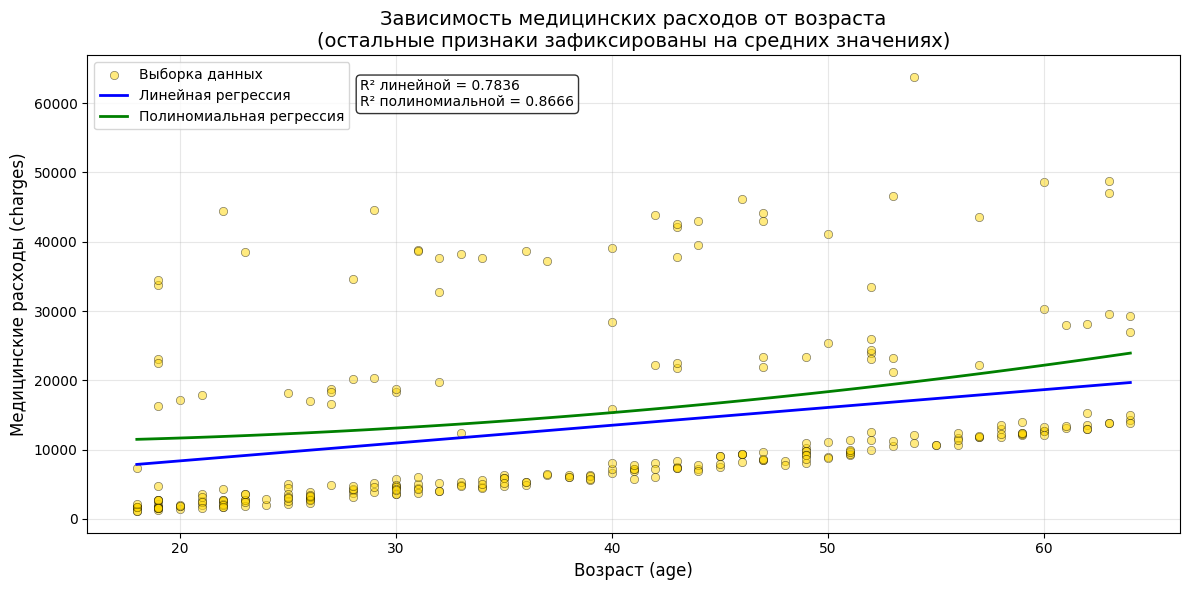

In [34]:
plt.figure(figsize=(12, 6))
age_min = X_test['age'].min()
age_max = X_test['age'].max()
age_range = np.linspace(age_min, age_max, 100)

mean_values = X_train.mean().to_dict()
X_for_plot = pd.DataFrame([mean_values] * 100)
X_for_plot['age'] = age_range
X_for_plot = X_for_plot[X_train.columns]

y_pred_lr_age = lr.predict(X_for_plot)
X_for_plot_poly = poly.transform(X_for_plot)
y_pred_poly_age = poly_model.predict(X_for_plot_poly)

plt.scatter(X_test['age'], y_test, alpha=0.5, color='gold', edgecolors='black', linewidth=0.5, label='Выборка данных')

plt.plot(age_range, y_pred_lr_age, 'b-', linewidth=2, label='Линейная регрессия')

plt.plot(age_range, y_pred_poly_age, 'g-', linewidth=2, label='Полиномиальная регрессия')

plt.xlabel('Возраст (age)', fontsize=12)
plt.ylabel('Медицинские расходы (charges)', fontsize=12)
plt.title('Зависимость медицинских расходов от возраста\n(остальные признаки зафиксированы на средних значениях)', fontsize=14)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

plt.text(0.25, 0.95, f'R² линейной = {r2_lr:.4f}\nR² полиномиальной = {r2_poly:.4f}', 
         transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()